In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sqlalchemy import create_engine, text
import pickle
import os
import pathlib

# Detecta raiz do projeto
BASE_DIR = pathlib.Path(os.getcwd())
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DB_PATH = BASE_DIR / 'data' / 'banco.db'
engine  = create_engine(f'sqlite:///{DB_PATH}', echo=False)

# Carrega do SQLite
df = pd.read_sql('SELECT * FROM tb_clientes', engine)

NOMES_CLUSTERS = {
    0: 'Primeiros Passos',
    1: 'Trajetória Crescente',
    2: 'Potencial Oculto',
    3: 'Self Made',
    4: 'Old Money',
}

print(f"Banco: {DB_PATH}")
print(f"Clientes carregados: {len(df):,} | {len(df.columns)} colunas")
print(f"Missing values: {df.isnull().sum().sum()}")

Banco: c:\Users\caleb\Documents\SANTANDER-MOTOR-RECOMENDACAO\data\banco.db
Clientes carregados: 300,000 | 42 colunas
Missing values: 0


In [2]:
FEATURES_MODELO = [
    'renda_mensal',
    'salario_referencia',
    'score_credito',
    'saldo_medio',
    'media_transacoes_mes',
    'meses_relacionamento',
    'uso_app_dias_mes',
    'volume_cambio_usd',
    'qtd_produtos',
    'qtd_upgrades',
    'idade',
]

X = df[FEATURES_MODELO].copy()
print(f"Features selecionadas: {len(FEATURES_MODELO)}")
print(f"Missing values: {X.isnull().sum().sum()}")
print(X.describe().round(2))

Features selecionadas: 11
Missing values: 0
       renda_mensal  salario_referencia  score_credito  saldo_medio  \
count     300000.00           300000.00      300000.00    300000.00   
mean       12098.42            10337.45         485.79      5483.85   
std        15241.37            14614.69          86.50      8381.06   
min          800.00             1600.00         119.00       110.88   
25%         5491.36             3500.00         452.00      1680.17   
50%         7615.97             7000.00         484.00      3148.07   
75%        15000.00             9000.00         517.00      5924.20   
max       120000.00           120000.00        1000.00    321073.59   

       media_transacoes_mes  meses_relacionamento  uso_app_dias_mes  \
count             300000.00             300000.00         300000.00   
mean                  39.47                 97.99             13.90   
std                   54.33                 57.48              5.26   
min                    1.00     

In [3]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES_MODELO)

Calculando métricas K=2 até K=10...


  K=2 | Inércia: 2,175,128 | Silhouette: 0.6321


  K=3 | Inércia: 1,694,408 | Silhouette: 0.3226


  K=4 | Inércia: 1,534,873 | Silhouette: 0.1600


  K=5 | Inércia: 1,443,440 | Silhouette: 0.1494


  K=6 | Inércia: 1,355,930 | Silhouette: 0.1489


  K=7 | Inércia: 1,274,554 | Silhouette: 0.1554


  K=8 | Inércia: 1,211,294 | Silhouette: 0.1533


  K=9 | Inércia: 1,161,203 | Silhouette: 0.1507


  K=10 | Inércia: 1,119,446 | Silhouette: 0.1459


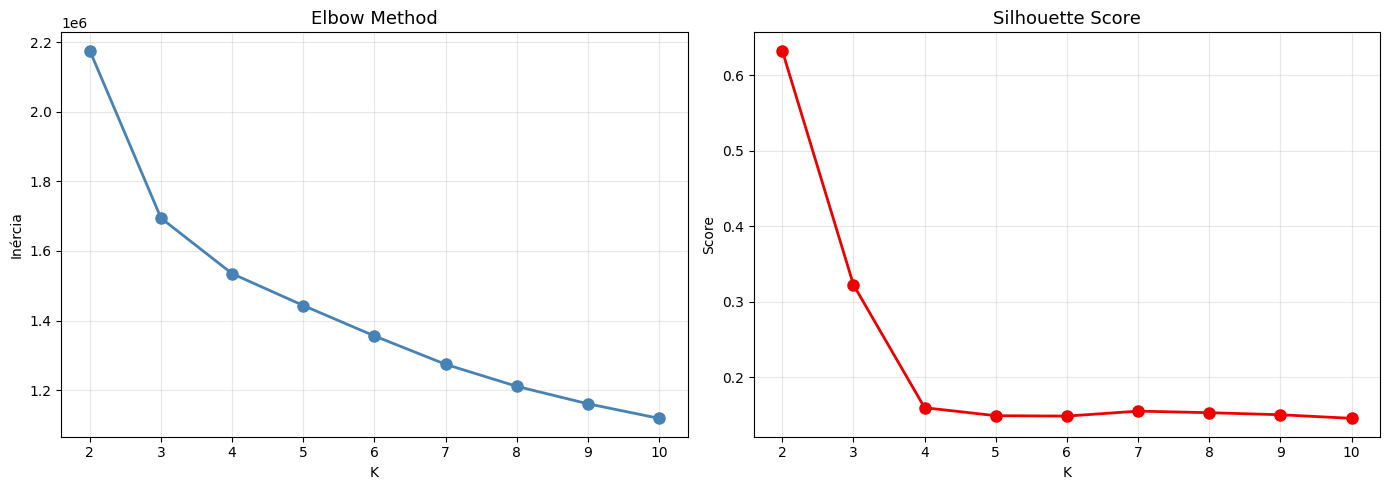

Gráfico salvo!


In [4]:
inercias    = []
silhouettes = []
K_range     = range(2, 11)

print("Calculando métricas K=2 até K=10...")
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f"  K={k} | Inércia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inercias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'o-', color='#EC0000', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'docs' / 'elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

In [5]:
K_IDEAL  = 5
km_final = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42)
db_score  = davies_bouldin_score(X_scaled, df['cluster'])

print(f"K definido: {K_IDEAL}")
print(f"Silhouette Score:    {sil_final:.4f}")
print(f"Davies-Bouldin:      {db_score:.4f}")
print(f"\nDistribuição dos clusters:")
print(df['cluster'].value_counts().sort_index())

K definido: 5
Silhouette Score:    0.1494
Davies-Bouldin:      1.6087

Distribuição dos clusters:
cluster
0    64079
1    15161
2    98729
3    94225
4    27806
Name: count, dtype: int64


In [6]:
# Mapeia cluster para nome baseado na renda média
renda_por_cluster = df.groupby('cluster')['renda_mensal'].mean().sort_values()
clusters_ordenados = renda_por_cluster.index.tolist()

# Menor renda = Primeiros Passos, maior = Old Money
mapa_automatico = {
    clusters_ordenados[0]: 0,  # Primeiros Passos
    clusters_ordenados[1]: 1,  # Trajetória Crescente
    clusters_ordenados[2]: 2,  # Potencial Oculto
    clusters_ordenados[3]: 3,  # Self Made
    clusters_ordenados[4]: 4,  # Old Money
}

df['cluster_id']   = df['cluster'].map(mapa_automatico)
df['cluster_nome'] = df['cluster_id'].map(NOMES_CLUSTERS)

print("=== PERFIL POR CLUSTER ===")
resumo = df.groupby(['cluster_id','cluster_nome']).agg(
    qtd_clientes       = ('id_cliente', 'count'),
    renda_media        = ('renda_mensal', 'mean'),
    score_medio        = ('score_credito', 'mean'),
    media_produtos     = ('qtd_produtos', 'mean'),
    idade_media        = ('idade', 'mean'),
    meses_medio        = ('meses_relacionamento', 'mean'),
    inadimplencia      = ('teve_inadimplencia_12m', 'mean'),
).reset_index()

for _, row in resumo.iterrows():
    print(f"\n  [{row['cluster_id']}] {row['cluster_nome']}")
    print(f"      Clientes:    {int(row['qtd_clientes']):,} ({row['qtd_clientes']/len(df):.1%})")
    print(f"      Renda média: R$ {row['renda_media']:,.0f}")
    print(f"      Score:       {row['score_medio']:.0f}")
    print(f"      Produtos:    {row['media_produtos']:.1f}")
    print(f"      Idade média: {row['idade_media']:.0f} anos")
    print(f"      Meses rel.:  {row['meses_medio']:.0f}")
    print(f"      Inadimp.:    {row['inadimplencia']:.1%}")

=== PERFIL POR CLUSTER ===

  [0] Primeiros Passos
      Clientes:    27,806 (9.3%)
      Renda média: R$ 3,816
      Score:       426
      Produtos:    2.4
      Idade média: 26 anos
      Meses rel.:  29
      Inadimp.:    11.2%

  [1] Trajetória Crescente
      Clientes:    98,729 (32.9%)
      Renda média: R$ 6,894
      Score:       462
      Produtos:    4.0
      Idade média: 37 anos
      Meses rel.:  86
      Inadimp.:    6.4%

  [2] Potencial Oculto
      Clientes:    94,225 (31.4%)
      Renda média: R$ 7,274
      Score:       470
      Produtos:    4.5
      Idade média: 38 anos
      Meses rel.:  92
      Inadimp.:    6.4%

  [3] Self Made
      Clientes:    64,079 (21.4%)
      Renda média: R$ 17,190
      Score:       514
      Produtos:    6.0
      Idade média: 43 anos
      Meses rel.:  143
      Inadimp.:    3.0%

  [4] Old Money
      Clientes:    15,161 (5.1%)
      Renda média: R$ 69,643
      Score:       726
      Produtos:    6.7
      Idade média: 55 anos
  

Variância explicada: 62.1%


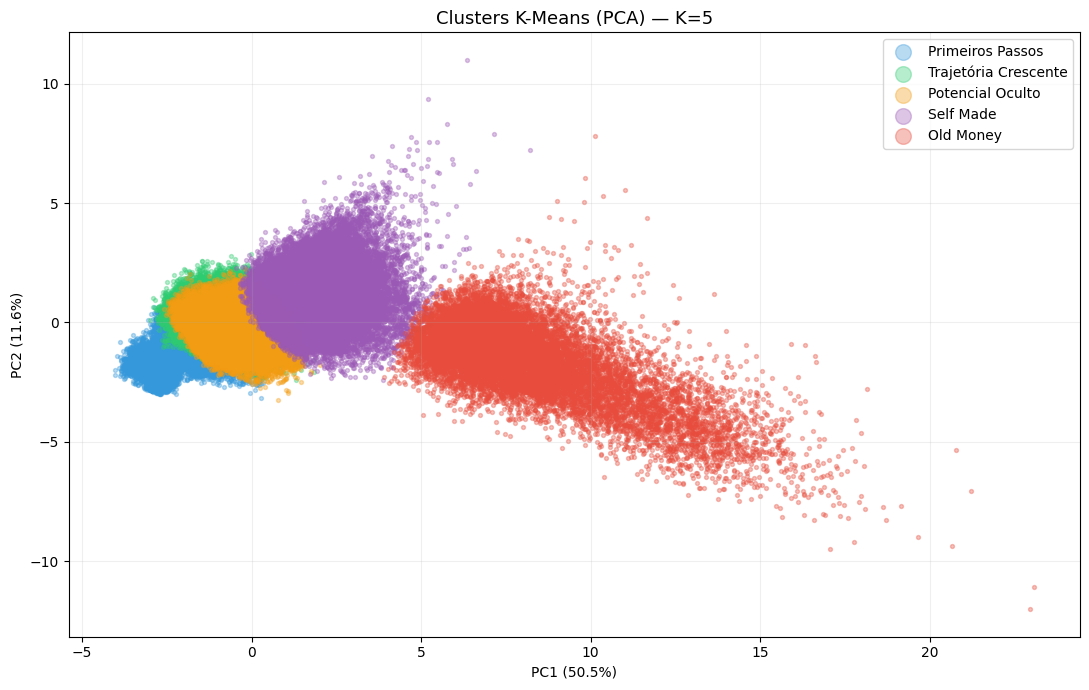

In [7]:
pca  = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.1%}")

cores = ['#3498db','#2ecc71','#f39c12','#9b59b6','#e74c3c']
plt.figure(figsize=(11, 7))

for cid in sorted(df['cluster_id'].unique()):
    mask = df['cluster_id'] == cid
    plt.scatter(X_pca[mask,0], X_pca[mask,1],
                c=cores[cid], label=NOMES_CLUSTERS[cid],
                alpha=0.35, s=8)

plt.title(f'Clusters K-Means (PCA) — K={K_IDEAL}', fontsize=13)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(markerscale=4, fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'docs' / 'clusters_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Salva modelo e scaler
os.makedirs(BASE_DIR / 'models', exist_ok=True)
with open(BASE_DIR / 'models' / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(BASE_DIR / 'models' / 'kmeans.pkl', 'wb') as f:
    pickle.dump(km_final, f)
with open(BASE_DIR / 'models' / 'mapa_clusters.pkl', 'wb') as f:
    pickle.dump(mapa_automatico, f)

print("Modelos salvos!")

# Atualiza tb_clientes com cluster
df_update = df[['id_cliente','cluster_id','cluster_nome']].copy()

with engine.connect() as conn:
    conn.execute(text("ALTER TABLE tb_clientes ADD COLUMN cluster_id INTEGER")) if 'cluster_id' not in pd.read_sql("PRAGMA table_info(tb_clientes)", engine)['name'].values else None
    conn.execute(text("ALTER TABLE tb_clientes ADD COLUMN cluster_nome TEXT")) if 'cluster_nome' not in pd.read_sql("PRAGMA table_info(tb_clientes)", engine)['name'].values else None
    conn.commit()

# Salva tabela de clusters separada
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS tb_clusters"))
    conn.commit()

df[['id_cliente','cluster_id','cluster_nome']].to_sql(
    'tb_clusters', engine, if_exists='replace', index=False
)

# Salva perfil dos clusters
resumo.to_sql('tb_perfil_clusters', engine, if_exists='replace', index=False)

print("Tabelas salvas no SQLite!")
with engine.connect() as conn:
    for row in conn.execute(text("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")):
        count = conn.execute(text(f"SELECT COUNT(*) FROM {row[0]}")).scalar()
        print(f"  {row[0]:25} | {count:,} registros")

Modelos salvos!


Tabelas salvas no SQLite!
  tb_clientes               | 300,000 registros
  tb_clusters               | 300,000 registros
  tb_depara                 | 5 registros
  tb_depara_clientes        | 300,000 registros
  tb_estados_cidades        | 64 registros
  tb_ibge_salarios          | 69 registros
  tb_perfil_clusters        | 5 registros
  tb_propensao              | 300,000 registros
  tb_rfm                    | 300,000 registros
